# A.I 머신러닝(Machine Learning) 시험 대비 모의 시험

## 자동차 외형 및 성능 데이터(Specifications)를 이용한 가격 예측 모델링

---

### 보험 관련 (2개)

| 컬럼 | 타입 | 설명 |
|---|---|---|
| **symboling** | int | 보험 위험 등급 (-3=안전 ~ +3=위험) |
| **normalized-losses** | object | 보험 손실금 정규화 수치 (65~256, 클수록 손해 큼) |

### 차량 기본 정보 (7개)

| 컬럼 | 타입 | 설명 |
|---|---|---|
| **make** | object | 제조사 (toyota, bmw, honda 등 22개 브랜드) |
| **fuel-type** | object | 연료 타입 (gas / diesel) |
| **aspiration** | object | 흡기 방식 (std=자연흡기 / turbo=터보) |
| **num-of-doors** | object | 문 개수 (two / four) |
| **body-style** | object | 차체 형태 (sedan, hatchback, wagon, convertible, hardtop) |
| **drive-wheels** | object | 구동 방식 (fwd=전륜 / rwd=후륜 / 4wd=사륜) |
| **engine-location** | object | 엔진 위치 (front / rear) |

### 차체 치수 (5개)

| 컬럼 | 타입 | 설명 |
|---|---|---|
| **wheel-base** | float | 축거 — 앞바퀴~뒷바퀴 거리 (인치) |
| **length** | float | 차량 전체 길이 (인치) |
| **width** | float | 차량 폭 (인치) |
| **height** | float | 차량 높이 (인치) |
| **curb-weight** | int | 공차 중량 — 빈 차의 무게 (파운드) |

### 엔진 사양 (8개)

| 컬럼 | 타입 | 설명 |
|---|---|---|
| **engine-type** | object | 엔진 타입 (ohc, dohc, ohcv 등 7종) |
| **num-of-cylinders** | object | 실린더 수 (four, six, eight 등 문자열) |
| **engine-size** | int | 엔진 배기량 (cc) |
| **fuel-system** | object | 연료 공급 방식 (mpfi, 2bbl, idi 등 8종) |
| **bore** | object | 실린더 내경 — 피스톤 지름 (인치) |
| **stroke** | object | 피스톤 행정 — 피스톤 이동 거리 (인치) |
| **compression-ratio** | float | 압축비 (가솔린 ~10, 디젤 ~22) |
| **horsepower** | object | 마력 (엔진 출력) |

### 성능 (3개)

| 컬럼 | 타입 | 설명 |
|---|---|---|
| **peak-rpm** | object | 최대 출력 회전수 (rpm) |
| **city-mpg** | int | 시내 연비 (miles per gallon, 클수록 좋음) |
| **highway-mpg** | int | 고속도로 연비 (mpg) |

### 타겟 변수 (1개)

| 컬럼 | 타입 | 설명 |
|---|---|---|
| **price** | object | 차량 가격 (달러) — **예측 대상** |

## 데이터 분석 (20점)
1. pandas는 데이터 분석에 널리 사용되는 파이썬 라이브러리입니다.  
pandas를 사용할 수 있게 별칭(alias)을 pd로 해서 불러오세요.  

In [60]:
import pandas as pd

2. AI 모델링을 위해 분석 및 처리할 데이터 파일을 읽어오려고 합니다.  
pandas로 데이터 파일을 읽어온 뒤, 데이터프레임 변수명 df에 할당하고 첫 4개 행을 출력하세요.

---

- 데이터프레임 변수명 : df
- 데이터 파일명 : Automobile_data.csv
- 데이터 파일 위치 : pandas/data/


In [61]:
# 답안 2.
df = pd.read_csv('pandas/data/Automobile_data.csv')
df.head(4)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950


### 다음 문항을 풀기전에 아래 코드를 실행하세요

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 윈도우용으로 아래 한글 나오게 하기 위해 사용함.
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

3. 시각화를 통해 네비게이션 목적지 주소1(Address1)의 분포를 파악하려 합니다

    - 3-1. 아래 가이드에 따라 seaborn 라이브러리를 활용해서 시각화하세요
        - 대상 데이터프레임: df
        - 각 제조자(make)들의 데이터 개수를 도어수(num-of-doors)별로 보여주는 countplot 그래프를 그리세요.
        - 그래프는 10,4 비율로 설정하세요.
        - x축 항목들이 겹쳐보이면 45도 기울여 표시하도록 하세요.
        - 그래프 요소(제목, 축 레이블, 범례 등)가 서로 겹치지 않도록 여백을 자동 조정하는 함수를 사용하세요.(tight_layout)
        - 그래프 출력 함수를 사용하세요(show)

    - 3-2. four 도어가 가장 많은 브랜드(make)는 어느 브랜드(make)인가요?
    - 다음과 같이 # 답안 3-2. 셀(cell)에 변수 답안3_2 를 만들고 값을 할당하세요
        - 예제) 답안3_2 = 'xxxx'

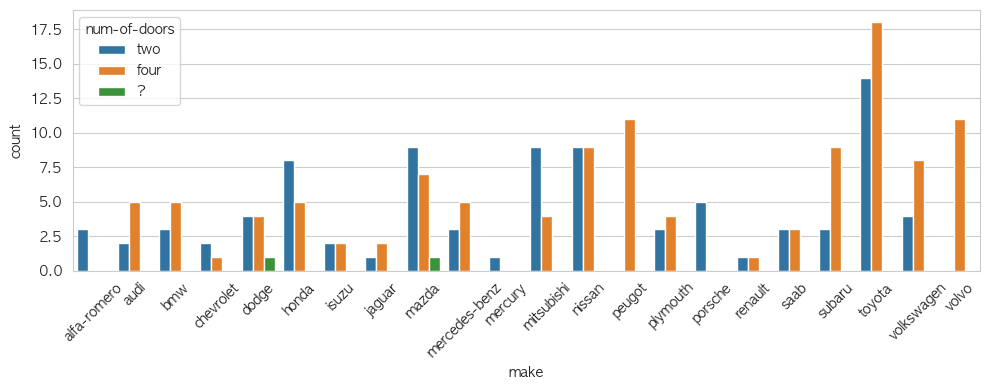

In [63]:
# 답안 3-1.
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='make', hue='num-of-doors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
# 답안 3-2.


4. 데이터프레임의 인덱스, 컬럼 및 컬럼수, 컬럼별 결측치, 컬럼별 데이터 타입등의 기본정보를 확인하는 코드를 작성하고 실행하세요.
    - 대상 데이터 프레임 : df

In [65]:
# 답안 4.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

5. 데이터프레임 df는 결측치는 물론 잠재적인 결측치 '?'가 들어있는 데이터들이 존재합니다. '?'가 들어있는 모든 데이터를 결측치(NaN)데이터로 변경하는 코드를 작성하세요
    - 5-1. 
    - 대상 데이터프레임 df를 df_copy로 복사하여 사용하세요.
    - df_copy에서 '?' 데이터를 모두 결측치(NaN)으로 수정하는 코드를 작성하세요.
    - df_copy의 모든 컬럼들의 결측치 개수를 확인하는 코드를 작성하고 결측치를 확인하세요

In [66]:
# 답안 5-1.
df_copy = df.copy()
df_copy = df_copy.replace('?', np.nan)
df_copy.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [67]:
# 답안 5-2.
df_copy = df_copy.drop(['symboling', 'normalized-losses'], axis=1)
df_copy.isnull().sum()

make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                4
dtype: int64

In [68]:
cols = df_copy.select_dtypes('object')
for col in cols:
    try:
        df_copy[col] = df_copy[col].astype(float)
    except ValueError as e:
        print(f'{col}: {e}')
        continue
df_copy.info()

make: could not convert string to float: 'alfa-romero'
fuel-type: could not convert string to float: 'gas'
aspiration: could not convert string to float: 'std'
num-of-doors: could not convert string to float: 'two'
body-style: could not convert string to float: 'convertible'
drive-wheels: could not convert string to float: 'rwd'
engine-location: could not convert string to float: 'front'
engine-type: could not convert string to float: 'dohc'
num-of-cylinders: could not convert string to float: 'four'
fuel-system: could not convert string to float: 'mpfi'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               205 non-null    object 
 1   fuel-type          205 non-null    object 
 2   aspiration         205 non-null    object 
 3   num-of-doors       203 non-null    object 
 4   body-style         205 non-null    object

In [69]:
df_copy.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


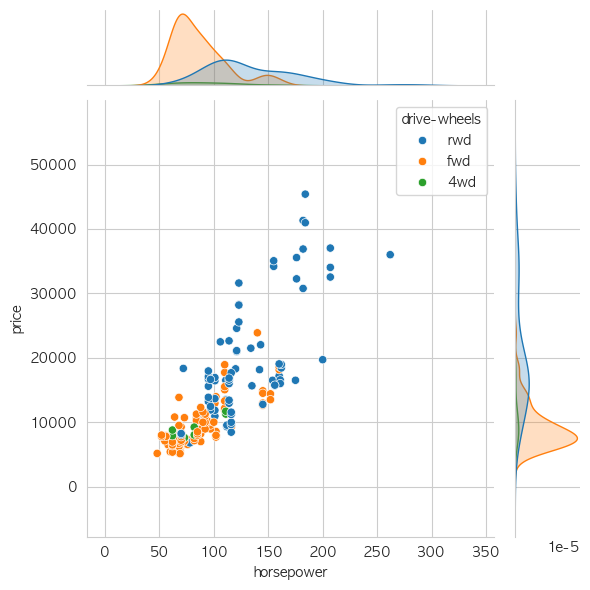

In [70]:
sns.jointplot(df_copy, x='horsepower', y='price', hue='drive-wheels', height=6)
plt.tight_layout()
plt.show()

<Axes: xlabel='num-of-doors', ylabel='price'>

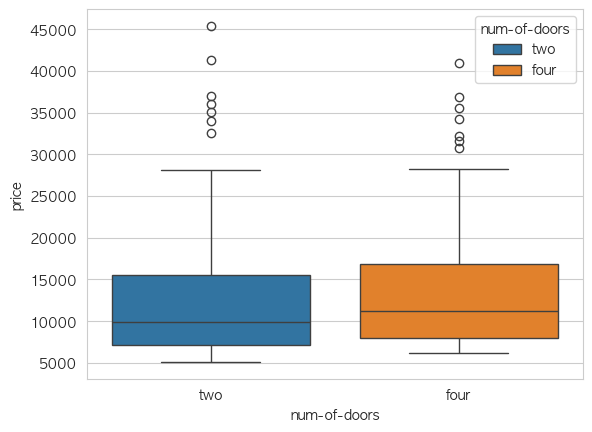

In [71]:
# door별 price
sns.boxplot(data=df_copy, x='num-of-doors', y='price', hue='num-of-doors')

<Axes: xlabel='drive-wheels', ylabel='horsepower'>

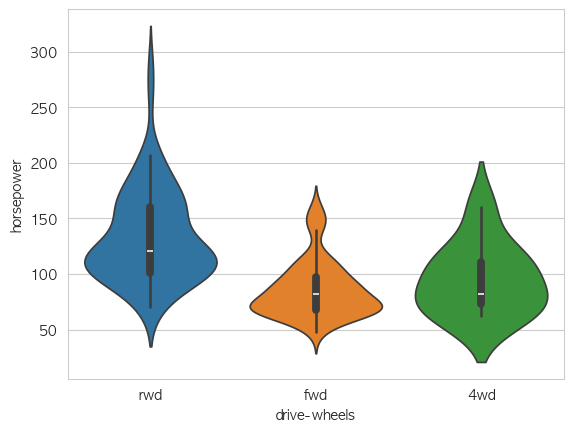

In [72]:
sns.violinplot(data=df_copy, x='drive-wheels', y='horsepower', hue='drive-wheels')

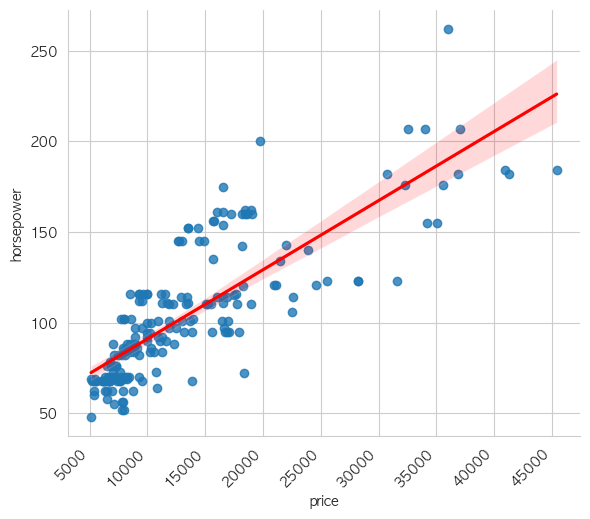

In [73]:
sns.lmplot(df_copy, x='price', y='horsepower', line_kws={'color':'red'}, aspect=1.2)
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='count', ylabel='body-style'>

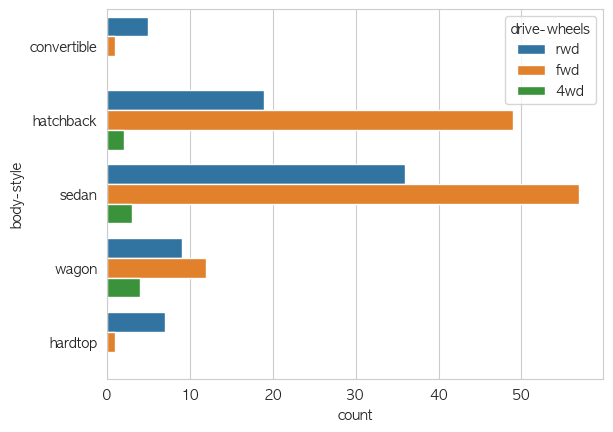

In [76]:
sns.countplot(df_copy, y='body-style', hue='drive-wheels')

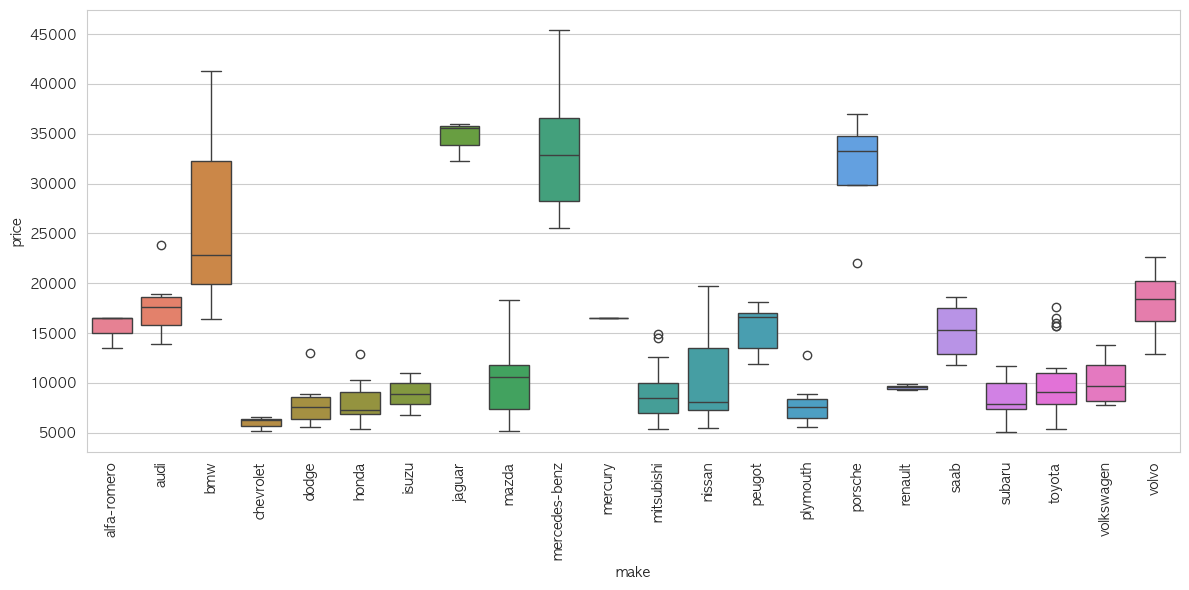

In [90]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_copy, y='price', x='make', hue='make')
plt.xticks(rotation=90)
plt.tight_layout()

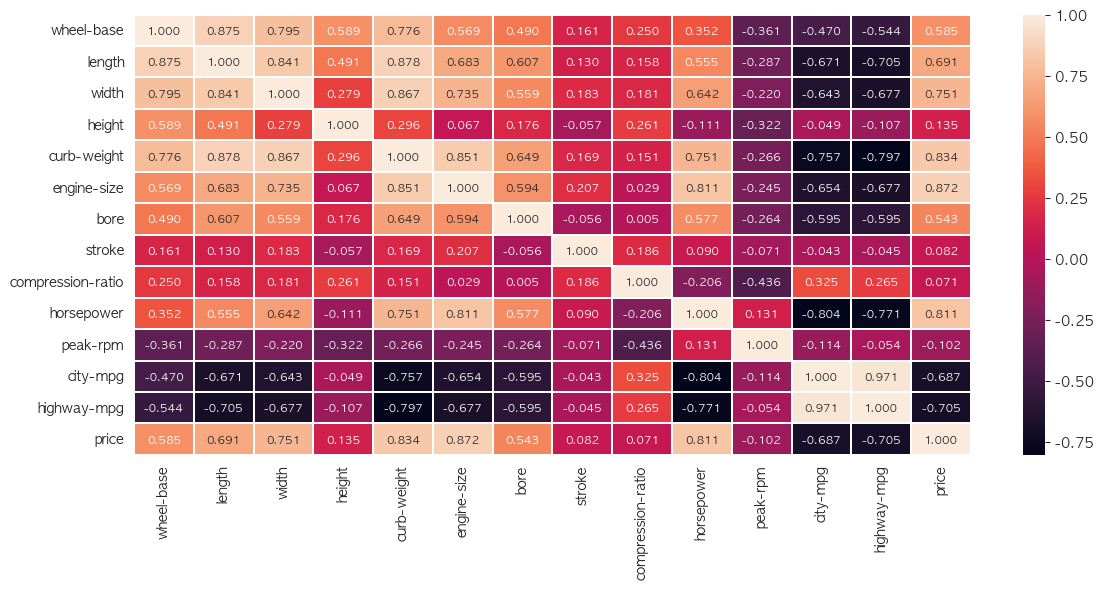

In [23]:
plt.figure(figsize=(12,6))
sns.heatmap(df_copy.corr(numeric_only=True), annot=True, fmt='.3f', linewidths=0.2, annot_kws={'size': 8})
plt.tight_layout()
plt.show()

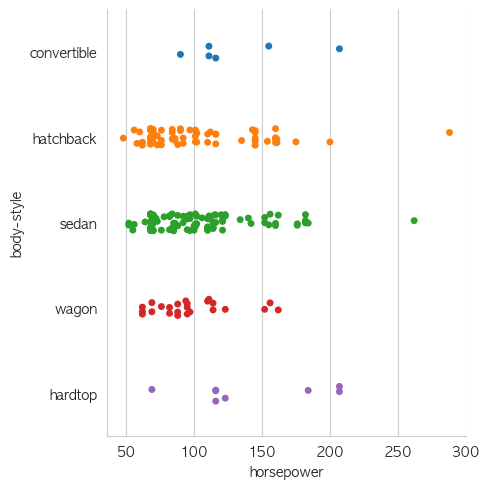

In [24]:
sns.catplot(data=df_copy, y='body-style', x='horsepower', hue='body-style')

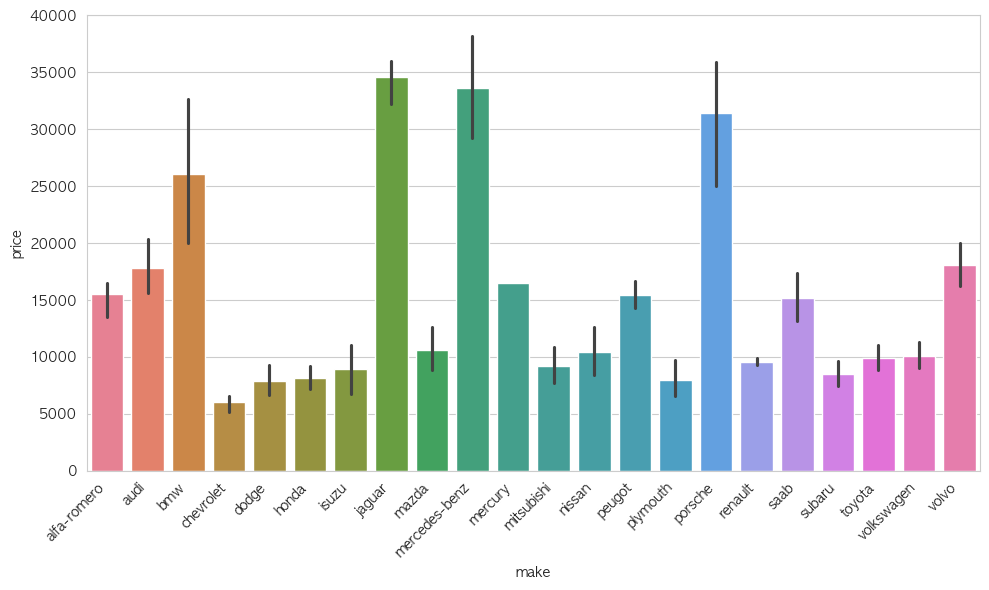

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_copy, x='make', y='price', hue='make')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


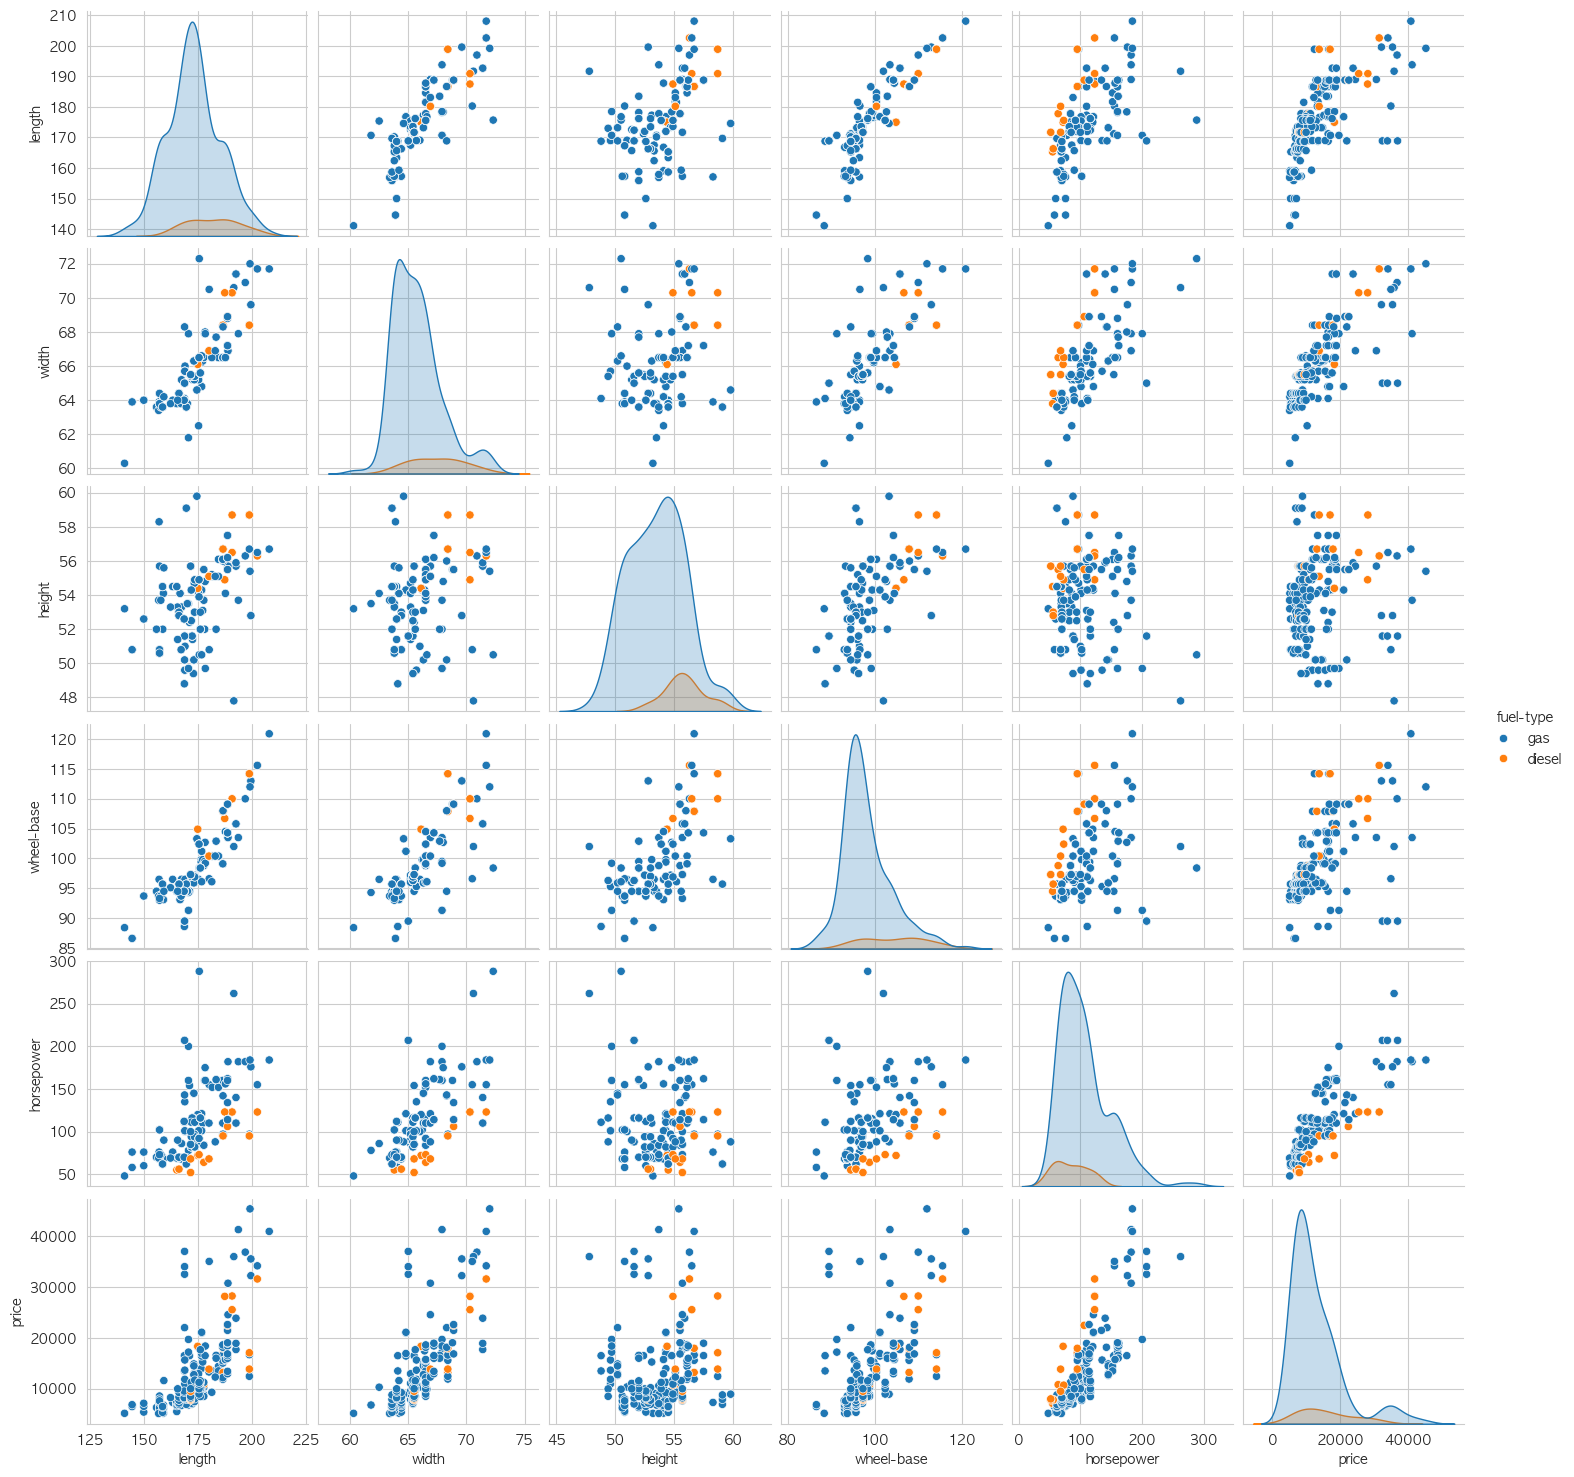

In [26]:
sns.pairplot(data=df_copy, 
             hue='fuel-type', 
             vars=['length', 'width', 'height', 'wheel-base', 'horsepower', 'price'],
             diag_kind='kde'
             )

In [27]:
df_na = df_copy.isnull()
df_na.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


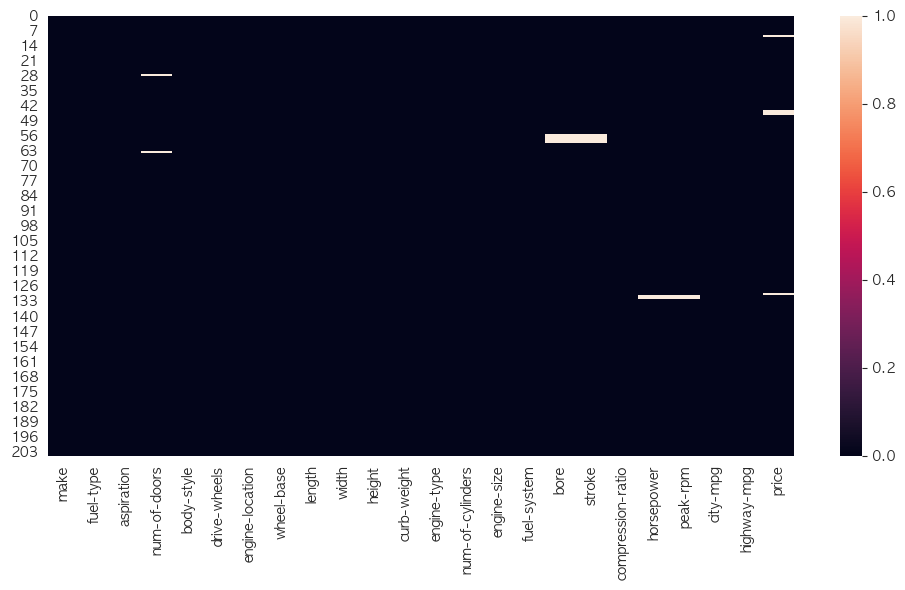

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df_na)
plt.tight_layout()
plt.show()


In [29]:
# num-of-doors 컬럼의 결측치 처리
df_copy['num-of-doors'] = df_copy['num-of-doors'].fillna(df_copy['num-of-doors'].mode()[0])

df_copy['bore'] = df_copy['bore'].fillna(df_copy['bore'].mean())
df_copy['stroke'] = df_copy['stroke'].fillna(df_copy['stroke'].mean())
df_copy['horsepower'] = df_copy['horsepower'].fillna(df_copy['horsepower'].mean())
df_copy['peak-rpm'] = df_copy['peak-rpm'].fillna(df_copy['peak-rpm'].mean())
df_copy['price'] = df_copy['price'].fillna(df_copy['price'].mean())

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               205 non-null    object 
 1   fuel-type          205 non-null    object 
 2   aspiration         205 non-null    object 
 3   num-of-doors       205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   wheel-base         205 non-null    float64
 8   length             205 non-null    float64
 9   width              205 non-null    float64
 10  height             205 non-null    float64
 11  curb-weight        205 non-null    int64  
 12  engine-type        205 non-null    object 
 13  num-of-cylinders   205 non-null    object 
 14  engine-size        205 non-null    int64  
 15  fuel-system        205 non-null    object 
 16  bore               205 non

### 이상치 확인하기

In [30]:
# 이상치 확인하기
def get_iqr(col):
    iqr1 = df_copy[col].quantile(0.25)
    iqr3 = df_copy[col].quantile(0.75)
    iqr = iqr3 - iqr1
    upper_boud = iqr3 + iqr * 1.5
    lower_bound = iqr1 - iqr * 1.5
    df_upper = df_copy[df_copy[col]>upper_boud]
    df_lower = df_copy[df_copy[col]<lower_bound]
    upper_len = len(df_upper)
    lower_len = len(df_lower)
    return {'column':col, 'IQR1': iqr1, 'IQR3':iqr3, 'IQR':iqr, 
            '최대값': df_copy[col].max(), '상한값':upper_boud, '상한개수':upper_len, 
            '평균값': df_copy[col].mean().round(2),
            '최소값': df_copy[col].min(), '하한값':lower_bound, '하한개수':lower_len, '이상치 개수':upper_len+lower_len, 
            }

result = []
cols = df_copy.select_dtypes('number')
for col in cols:
    result.append(get_iqr(col))

df_iqr_info = pd.DataFrame(result)
df_iqr_info.set_index('column', inplace=True)
df_iqr_info


,IQR1,IQR3,IQR,최대값,상한값,상한개수,평균값,최소값,하한값,하한개수,이상치 개수
column,,,,,,,,,,,
wheel-base,94.50,102.40,7.90,120.90,114.250,3,98.76,86.60,82.650,0,3
length,166.30,183.10,16.80,208.10,208.300,0,174.05,141.10,141.100,1,1
width,64.10,66.90,2.80,72.30,71.100,8,65.91,60.30,59.900,0,8
height,52.00,55.50,3.50,59.80,60.750,0,53.72,47.80,46.750,0,0
curb-weight,2145.00,2935.00,790.00,4066.00,4120.000,0,2555.57,1488.00,960.000,0,0
engine-size,97.00,141.00,44.00,326.00,207.000,10,126.91,61.00,31.000,0,10
bore,3.15,3.58,0.43,3.94,4.225,0,3.33,2.54,2.505,0,0
stroke,3.11,3.41,0.30,4.17,3.860,5,3.26,2.07,2.660,15,20
compression-ratio,8.60,9.40,0.80,23.00,10.600,21,10.14,7.00,7.400,7,28


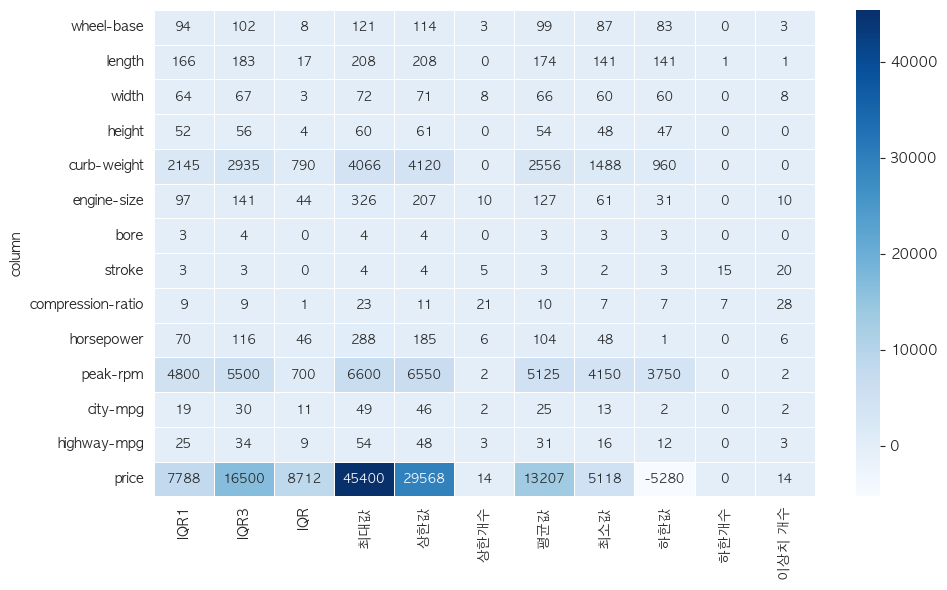

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_iqr_info, annot=True, fmt='.0f', linewidths=0.5, cmap='Blues', annot_kws={'fontsize':9})
plt.tight_layout()
plt.show()

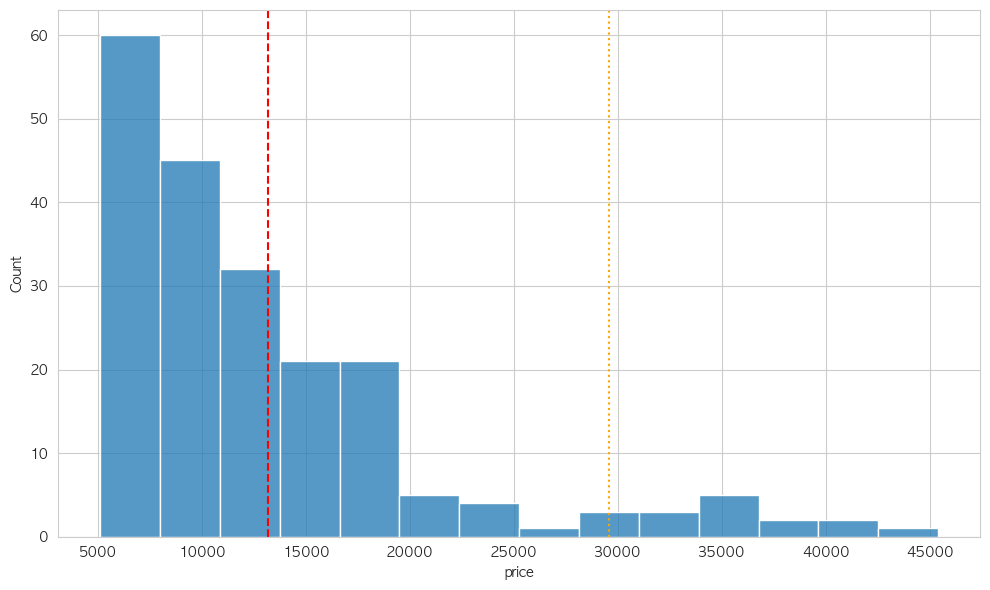

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df_copy, x='price')
plt.axvline(df_copy['price'].mean(), color='red', linestyle='--')
plt.axvline(df_iqr_info['상한값']['price'], color='orange', linestyle=':')
plt.tight_layout()
plt.show()

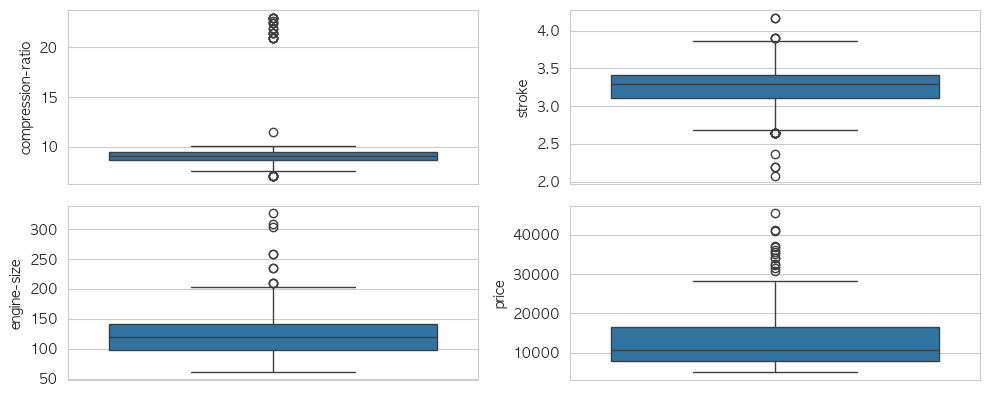

In [39]:
fig, axes = plt.subplots(2,2, figsize=(10,4))
sns.boxplot(data=df_copy, y='compression-ratio', ax=axes[0,0])
sns.boxplot(data=df_copy, y='stroke', ax=axes[0,1])
sns.boxplot(data=df_copy, y='engine-size', ax=axes[1,0])
sns.boxplot(data=df_copy, y='price', ax=axes[1,1])
plt.tight_layout()
plt.show()

In [71]:
df_enc = pd.get_dummies(df_copy, drop_first=True, dtype='i1')
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 64 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   wheel-base               205 non-null    float64
 1   length                   205 non-null    float64
 2   width                    205 non-null    float64
 3   height                   205 non-null    float64
 4   curb-weight              205 non-null    int64  
 5   engine-size              205 non-null    int64  
 6   bore                     205 non-null    float64
 7   stroke                   205 non-null    float64
 8   compression-ratio        205 non-null    float64
 9   horsepower               205 non-null    float64
 10  peak-rpm                 205 non-null    float64
 11  city-mpg                 205 non-null    int64  
 12  highway-mpg              205 non-null    int64  
 13  price                    205 non-null    float64
 14  make_audi                2

In [72]:
# split
from sklearn.model_selection import train_test_split

X = df_enc.drop(['price'], axis=1)
y = df_enc['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'학습 데이터: X_train: {X_train.shape}, y_train:{y_train.shape}')
print(f'테스트 데이터: X_test: {X_test.shape}, y_train:{y_test.shape}')

학습 데이터: X_train: (164, 63), y_train:(164,)
테스트 데이터: X_test: (41, 63), y_train:(41,)


In [73]:
# scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# scaler = StandardScaler()
# sacler = MinMaxScaler()
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
# 선형 회귀 평가하기
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

eval_result = []
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse1 = np.sqrt(mse)
    rmse2 = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'name': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE1': rmse1,
        'RMSE2': rmse2,
        'R2_SCORE': r2
    }

In [75]:
# Machine Learning: Linear Regression
from sklearn.linear_model import LinearRegression

# 학습
lr = LinearRegression()
lr.fit(X_train_scaled, y_train) # 학습

# 예측
y_pred_lr = lr.predict(X_test_scaled)   # 반드시 스케일링된 데이터로 예측을 시도해야 함

# 평가
evaluated = evaluate_model('Linear Regression', y_test, y_pred_lr)
eval_result.append(evaluated)

evaluated

{'name': 'Linear Regression',
 'MAE': 1904.6772408522063,
 'MSE': 8371721.0780644445,
 'RMSE1': 2893.3926588115282,
 'RMSE2': 2893.3926588115282,
 'R2_SCORE': 0.8926318043385258}

In [76]:
# Machine Learning: Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor, plot_tree

dtr = DecisionTreeRegressor(max_depth=3, random_state=42)
dtr.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

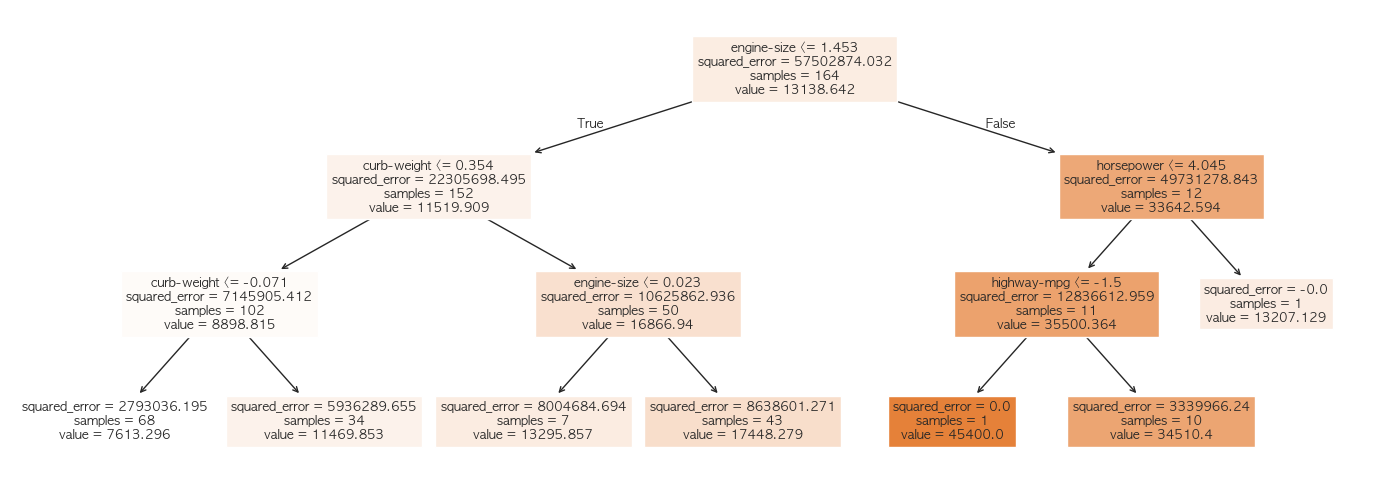

In [77]:
# ── 트리 구조 시각화 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))   # 가로 14, 세로 5인 그래프 공간 생성
plot_tree(dtr, feature_names=X.columns, class_names=['price'], filled=True, fontsize=9, ax=ax)
plt.tight_layout()
plt.show()

In [78]:

y_pred_dtr = dtr.predict(X_test_scaled)
evaluated = evaluate_model('Decision Tree Regressor', y_test, y_pred_dtr)
eval_result.append(evaluated)
evaluated

{'name': 'Decision Tree Regressor',
 'MAE': 2607.712951076588,
 'MSE': 11972155.743870573,
 'RMSE1': 3460.0803088758753,
 'RMSE2': 3460.0803088758753,
 'R2_SCORE': 0.8464558543683911}

In [79]:
# Machine Learning: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

rfr.fit(X_train_scaled, y_train)

y_pred_rfr = rfr.predict(X_test_scaled)

evaluated = evaluate_model('Random Forest Regressor', y_test, y_pred_rfr)
eval_result.append(evaluated)
evaluated

{'name': 'Random Forest Regressor',
 'MAE': 1607.0928510866872,
 'MSE': 5163163.270191582,
 'RMSE1': 2272.2595076688713,
 'RMSE2': 2272.2595076688713,
 'R2_SCORE': 0.9337818927486012}

In [80]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_scaled, y_train)

y_pred_gbr = gbr.predict(X_test_scaled)

evaluated = evaluate_model('Gradient Boosting Regressor', y_test, y_pred_gbr)
eval_result.append(evaluated)
evaluated


{'name': 'Gradient Boosting Regressor',
 'MAE': 1693.2623196520644,
 'MSE': 5588079.400410649,
 'RMSE1': 2363.911885077498,
 'RMSE2': 2363.911885077498,
 'R2_SCORE': 0.9283322990768034}

In [81]:
df_eval = pd.DataFrame(eval_result)
df_eval

,name,MAE,MSE,RMSE1,RMSE2,R2_SCORE
0,Linear Regression,1904.677241,8.371721e+06,2893.392659,2893.392659,0.892632
1,Decision Tree Regressor,2607.712951,1.197216e+07,3460.080309,3460.080309,0.846456
2,Random Forest Regressor,1607.092851,5.163163e+06,2272.259508,2272.259508,0.933782
3,Gradient Boosting Regressor,1693.262320,5.588079e+06,2363.911885,2363.911885,0.928332


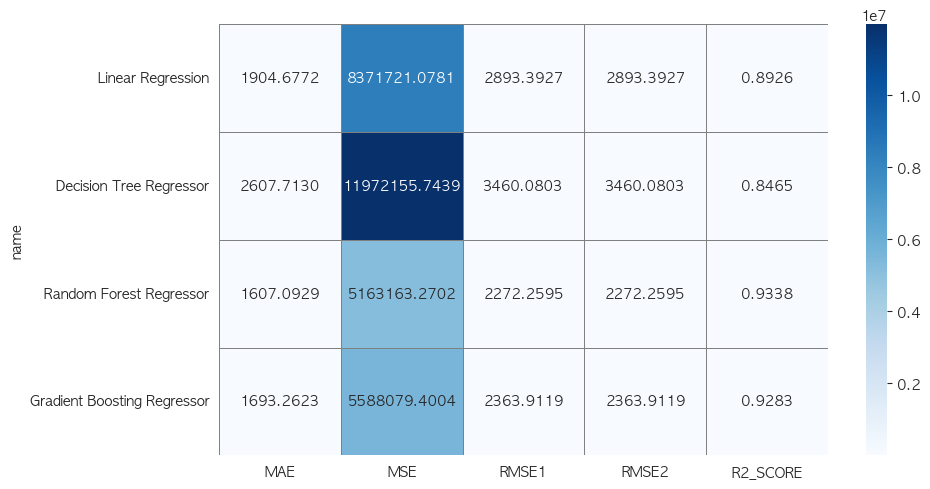

In [82]:
# 평가지표 히트맵
df_eval_corr = df_eval.set_index('name')
plt.figure(figsize=(10, 5))
sns.heatmap(df_eval_corr, annot=True, fmt='.4f', cmap='Blues', linecolor='grey', linewidths=0.5)
plt.tight_layout()
plt.show()


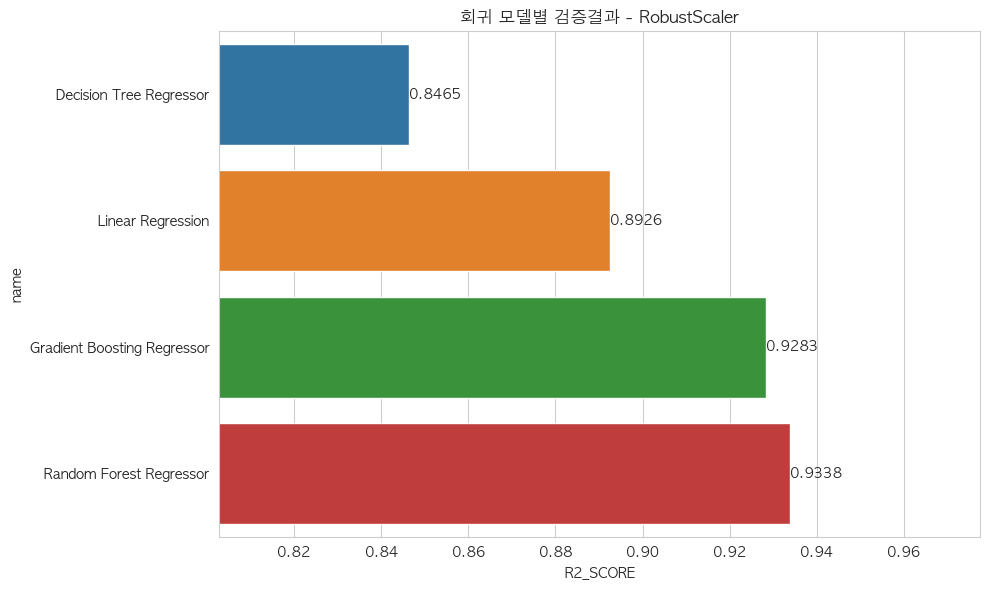

In [83]:
df_eval = df_eval.sort_values('R2_SCORE')
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=df_eval, y='name', x='R2_SCORE', hue='name', ax=ax)

# x축 범위를 데이터 최소~최대에 맞게 좁히기
min_val = df_eval['R2_SCORE'].min()
max_val = df_eval['R2_SCORE'].max()
margin = (max_val - min_val) * 0.5   # 여백 10%
ax.set_xlim(min_val - margin, max_val + margin)

# 각 막대 위에 R2_SCORE 값 표시
for i, (score, name) in enumerate(zip(df_eval['R2_SCORE'], df_eval['name'])):
    ax.text(x=score, y=i, s=f'{score:.4f}',
            va='center',    # 세로 중앙 정렬
            ha='left',      # 막대 끝에서 오른쪽으로 표시
            fontsize=10)

plt.title('회귀 모델별 검증결과 - RobustScaler')
plt.tight_layout()
plt.show()

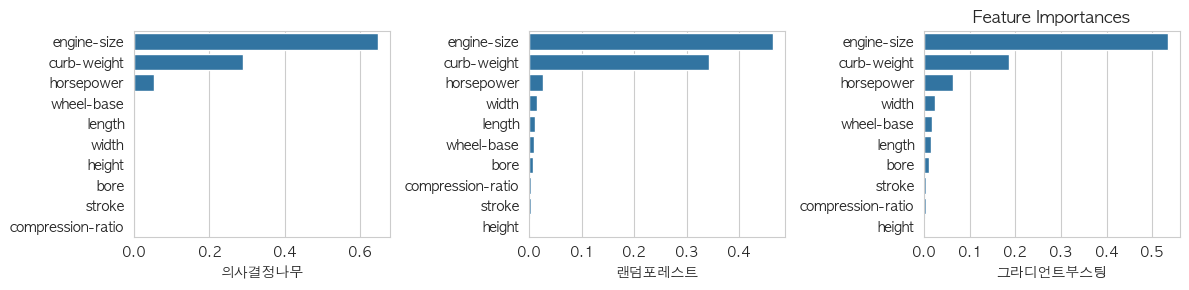

In [84]:
fig, ax = plt.subplots(1,3, figsize=(12,3))
for i, model, name in zip(np.arange(3), [dtr, rfr, gbr], ['의사결정나무', '랜덤포레스트', '그라디언트부스팅']):
    df_importance = pd.DataFrame(model.feature_importances_, columns=['value'], index=X_train.columns)
    df_importance = df_importance.head(10).sort_values('value', ascending=False)
    sns.barplot(data=df_importance, x='value', y=df_importance.index, ax=ax[i])
    ax[i].set_xlabel(name)
    ax[i].set_ylabel('')
    # df_importance.plot(kind='barh')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

In [85]:
# 모델 성능 개선: Hyper Parameter Tunning
from sklearn.model_selection import GridSearchCV

dt_params = {
    'max_depth': [2,3,5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1,2,5],
}

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3,5,7,10, None],
    'min_samples_split':[2, 3, 5, 10]
}

gb_params = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':[2, 3, 5],
    'subsample':[0.7, 0.8, 0.9],
    'min_samples_split': [5, 10, 15]
}

params = [dt_params, rf_params, gb_params]
regressors = [DecisionTreeRegressor(random_state=42), RandomForestRegressor(random_state=42), GradientBoostingRegressor(random_state=42)]
names = ['Decision Tree Regressor(Hyper Tuned)', 'Random Forest Regressor(Hyper Tuned)', 'Gradient Boosting Regressor(Hyper Tuned)']
for param, regressor, name in zip(params, regressors, names):
    res = GridSearchCV( regressor, param, scoring='r2', n_jobs=-1, cv=5 )
    res.fit(X_train_scaled, y_train)

    print(f'최적 파라미터: {res.best_params_}')
    print(f'최적 CV 점수: {res.best_score_:.4f}')

    y_pred = res.predict(X_test_scaled)
    eval_result.append(evaluate_model(name, y_test, y_pred))
    
df_eval = pd.DataFrame(eval_result)
df_eval

최적 파라미터: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
최적 CV 점수: 0.7969
최적 파라미터: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
최적 CV 점수: 0.8455
최적 파라미터: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.7}
최적 CV 점수: 0.8538


,name,MAE,MSE,RMSE1,RMSE2,R2_SCORE
0,Linear Regression,1904.677241,8.371721e+06,2893.392659,2893.392659,0.892632
1,Decision Tree Regressor,2607.712951,1.197216e+07,3460.080309,3460.080309,0.846456
2,Random Forest Regressor,1607.092851,5.163163e+06,2272.259508,2272.259508,0.933782
3,Gradient Boosting Regressor,1693.262320,5.588079e+06,2363.911885,2363.911885,0.928332
4,Decision Tree Regressor(Hyper Tuned),1697.908634,6.046581e+06,2458.979588,2458.979588,0.922452
5,Random Forest Regressor(Hyper Tuned),1486.501097,4.738188e+06,2176.737953,2176.737953,0.939232
6,Gradient Boosting Regressor(Hyper Tuned),1517.284664,5.591123e+06,2364.555478,2364.555478,0.928293


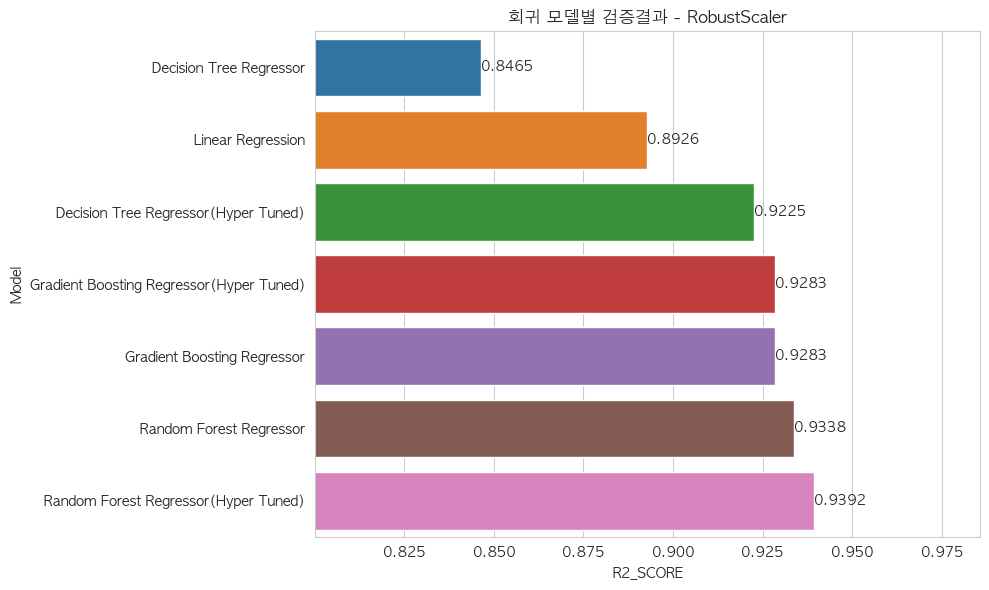

In [ ]:
df_eval = df_eval.sort_values('R2_SCORE')

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(df_eval, x='R2_SCORE', y='name', hue='name', formatter=lambda x:str(x))

# x축 범위를 데이터 최소~최대에 맞게 좁히기
min_val = df_eval['R2_SCORE'].min()
max_val = df_eval['R2_SCORE'].max()
margin = (max_val - min_val) * 0.5   # 타이트한 폭
ax.set_xlim(min_val - margin, max_val + margin)

# 각 막대 위에 R2_SCORE 값 표시
for i, (score, name) in enumerate(zip(df_eval['R2_SCORE'], df_eval['name'])):
    ax.text(x=score, y=i, s=f'{score:.4f}',
            va='center',    # 세로 중앙 정렬
            ha='left',      # 막대 끝에서 오른쪽으로 표시
            fontsize=10)

plt.title('회귀 모델별 검증결과 - RobustScaler')
plt.ylabel('Model')
plt.tight_layout()
plt.show()
